# **Internal Representations for Hallucination Detection in LLMs**

**Course:** Conversational AI - Winter 2026

This notebook reports a reproducible hallucination-detection pipeline built around **Llama-3.2-1B** internal representations. It uses TruthfulQA generations, hidden-state probes, spectral attention features, logit-dynamics features, XGBoost, LapEigvals-style logistic regression, and a gated multi-signal fusion model.


## **Abstract**

This project studies whether internal representations from a small open LLM can help detect hallucinated answers. We generate answers to TruthfulQA questions with Llama-3.2-1B, label them with a reproducible token-F1 heuristic, and extract three groups of internal signals: 
1. Mean-pooled hidden states
2. Graph-spectral attention features, and 
3. Early-versus-late logit dynamics. 
   
We compare 
1. Cheap text baselines
2. LapEigvals-style PCA plus logistic-regression probe
3. XGBoost on stacked features, and 
4. A gated fusion model that learns how much to rely on each signal for each example. 
   
The experiments show that internal signals are more useful than length-only heuristics, and that hidden states, attention spectra, and logit dynamics capture complementary information. The main limitations are noisy automatic labels, a single dataset, and the use of a 1B model for hardware reasons.


## **Introduction**

Hallucination detection is hard because false generations can look fluent, confident, and well formed. Prior work argues that hallucinations are not a single failure mode: some are overconfident falsehoods, while others come from uncertainty or missing knowledge [1]. This makes surface-level uncertainty signals incomplete. The generation-discrimination gap gives another motivation for this project: language models can contain factual information in intermediate representations even when the final decoder emits the wrong answer [2].

This notebook focuses on internal signals that can be extracted in a single forward trace:
1. Hidden states give a residual-stream view of the model's factual computation
2. Attention spectra summarize token-connectivity structure, 
3. Logit dynamics measure how much early and late layers disagree about the answer distribution. 

We use TruthfulQA because it targets common misconceptions and adversarially phrased factual questions [7]. The project reimplements the classifier side of LapEigvals [4] and adds a gated fusion probe that combines hidden, attention, and logit features in an interpretable way.


## **Methodology**

The pipeline has four main steps. 
1. First, Llama-3.2-1B generates one greedy answer per TruthfulQA question. Each generated answer is compared with the reference answers using token-level F1, producing a binary label where low overlap is treated as likely hallucination. This label is **imperfect**, but it is cheap, deterministic, and easy to rerun.

2. Second, the notebook extracts three internal feature blocks. Hidden-state features are mean-pooled residual-stream activations, with layers 8, 12, and 15 averaged later for the main classifier. Attention features follow the LapEigvals idea: each attention head is treated as a token graph, and top diagonal Laplacian values are used as spectral features [4]. Logit-dynamics features compare early and late layer output distributions through KL divergence and entropy.

3. Third, the classifiers test different ways of using those signals. Length is a text-only baseline. LapEigvals plus logistic regression tests the attention spectrum on its own. XGBoost is a strong tabular baseline on stacked internal features. The main project model is gated fusion: each modality is encoded into a small bottleneck, and a softmax gate learns per-example weights over hidden, attention, and logit streams.

4. Finally, ablations test which layers and modalities matter, while qualitative plots inspect the learned gates and selected attention maps.


## **Experimental Setup**

This section makes the notebook runnable. It sets up imports, loads the model, builds or loads the dataset splits, extracts cached internal features, and trains the baseline classifiers. The split is fixed by seed: training fits parameters, validation controls early stopping and tuning, and test metrics are reserved for final reporting.


### Environment and Imports

Run the optional Colab cell only when starting from a fresh hosted notebook. It uses `requirements-colab.txt`, which avoids reinstalling Colab's CUDA-enabled PyTorch stack. Local runs should use the environment from `setup.sh` or `requirements.txt`.

The two flags below control grading/runtime behavior:

- `RUN_FROM_SCRATCH = False` uses committed cached splits, features, metrics, and model checkpoints whenever available.
- `SKIP_MODEL_REQUIRED_CELLS = True` skips cells that require loading Llama through Hugging Face/nnsight. Set it to `False` if you have access to `meta-llama/Llama-3.2-1B` and want the live model-dependent checks.
- For full reproduction, use `RUN_FROM_SCRATCH = True` and `SKIP_MODEL_REQUIRED_CELLS = False`; rebuilding data and features cannot happen without Llama.


In [ ]:
# Colab setup. Uncomment on Google Colab
# Colab already provides a CUDA-ready torch install, so use the Colab requirements file.
# !git clone https://github.com/YOUR_USERNAME/conv-ai-project.git
# %cd conv-ai-project
# !pip install -r requirements-colab.txt -q

try:
    import google.colab  # type: ignore

    IN_COLAB = True
except Exception:
    IN_COLAB = False

print("Running in Colab:", IN_COLAB)

from pathlib import Path

if IN_COLAB:
    if not Path("/content/conv-ai-project").exists():
        !git clone https://github.com/YOUR_USERNAME/conv-ai-project.git /content/conv-ai-project
    %cd /content/conv-ai-project
    %pip install -r requirements-colab.txt -q


Running in Colab: False


In [13]:
import os
import sys
from pathlib import Path

# Main runtime switches. Keep these defaults for a quick cached Colab run.
RUN_FROM_SCRATCH = False
SKIP_MODEL_REQUIRED_CELLS = True

# project root: repo root (parent of this notebook folder)
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
ROOT = ROOT.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils.config import Config
from src.utils.reproducibility import set_seed

cfg = Config()
set_seed(cfg.seed)
print("ROOT", ROOT)
print("device", cfg.device, "model", cfg.model_name, "seed", cfg.seed)
print("RUN_FROM_SCRATCH", RUN_FROM_SCRATCH)
print("SKIP_MODEL_REQUIRED_CELLS", SKIP_MODEL_REQUIRED_CELLS)

if RUN_FROM_SCRATCH and SKIP_MODEL_REQUIRED_CELLS:
    raise ValueError(
        "RUN_FROM_SCRATCH=True requires loading Llama. Set "
        "SKIP_MODEL_REQUIRED_CELLS=False for full reproduction, or keep "
        "RUN_FROM_SCRATCH=False for a cached no-model run."
    )


ROOT /home/artypuppet/conversational-ai/conv-ai-project
device cuda model meta-llama/Llama-3.2-1B seed 42


In [14]:
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display

sns.set_context("paper")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

print("torch", torch.__version__, "cuda", torch.cuda.is_available())


torch 2.11.0+cu130 cuda True


### Model, Dataset, and Features

The model is loaded only when a run actually needs Llama. Cached mode can skip model loading and still show the core results. If split files or feature caches already exist, the notebook reuses them; with `RUN_FROM_SCRATCH = True`, it rebuilds them and writes fresh artifacts to disk.


In [15]:
# Loading Llama requires a Hugging Face token and license access for Meta Llama.
from src.extraction.model_loader import load_model

model_needed = RUN_FROM_SCRATCH or not SKIP_MODEL_REQUIRED_CELLS
if model_needed:
    print("Loading Llama model because this run needs model-dependent cells.")
    lm = load_model(cfg)
    m = lm._model
    n_params = sum(p.numel() for p in m.parameters())
    print("parameters (billions, approx):", n_params / 1e9)
    # shallow module names
    for name, _ in list(m.named_children())[:6]:
        print(" ", name)
else:
    lm = None
    print("Skipping Llama load: cached mode with SKIP_MODEL_REQUIRED_CELLS=True.")
    print("Set SKIP_MODEL_REQUIRED_CELLS=False to run live model-dependent cells.")


Loading weights:   1%|          | 1/146 [00:05<12:10,  5.03s/it]/home/artypuppet/conversational-ai/conv-ai-project/.venv/lib/python3.13/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 146/146 [00:07<00:00, 18.49it/s]


parameters (billions, approx): 0.749275136
  model
  lm_head
  generator


loaded existing splits from /home/artypuppet/conversational-ai/conv-ai-project/data
train: n=571 | 0: 270 (47.3%) | 1: 301 (52.7%)
val: n=123 | 0: 58 (47.2%) | 1: 65 (52.8%)
test: n=123 | 0: 58 (47.2%) | 1: 65 (52.8%)


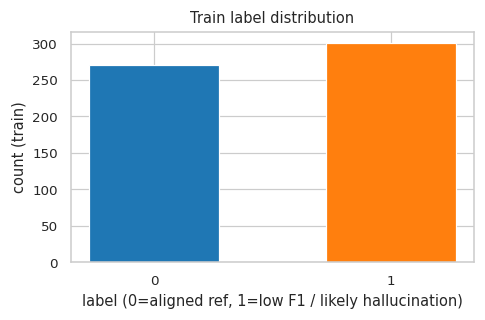

In [16]:
from src.data.dataset_builder import (
    build_dataset,
    load_splits,
    load_truthfulqa,
    print_label_stats,
    save_splits,
    split_dataset,
)

split_paths = [cfg.data_dir / name for name in ["train.pt", "val.pt", "test.pt"]]
splits_ready = all(path.is_file() for path in split_paths)

if RUN_FROM_SCRATCH:
    if lm is None:
        raise RuntimeError(
            "RUN_FROM_SCRATCH=True needs Llama. Set SKIP_MODEL_REQUIRED_CELLS=False "
            "and make sure Hugging Face access is configured."
        )
    print("RUN_FROM_SCRATCH=True: rebuilding TruthfulQA splits.")
    qa = load_truthfulqa()
    data = build_dataset(lm, qa, cfg, resume=True)
    tr, va, te = split_dataset(data, seed=cfg.seed)
    save_splits(tr, va, te, cfg.data_dir)
elif splits_ready:
    print("Using cached dataset splits from", cfg.data_dir)
    tr, va, te = load_splits(cfg.data_dir)
else:
    if lm is None:
        raise FileNotFoundError(
            "Cached split files are missing, and Llama loading is skipped. "
            "Either commit data/train.pt, data/val.pt, data/test.pt, or set "
            "SKIP_MODEL_REQUIRED_CELLS=False to build them."
        )
    print("No cached splits found: building dataset (long run).")
    qa = load_truthfulqa()
    data = build_dataset(lm, qa, cfg, resume=True)
    tr, va, te = split_dataset(data, seed=cfg.seed)
    save_splits(tr, va, te, cfg.data_dir)

print_label_stats(tr, "train")
print_label_stats(va, "val")
print_label_stats(te, "test")

c0 = sum(1 for d in tr if d["label"] == 0)
c1 = sum(1 for d in tr if d["label"] == 1)
fig, ax = plt.subplots(figsize=(4.5, 3))
ax.bar([0, 1], [c0, c1], color=["tab:blue", "tab:orange"], width=0.55)
ax.set_xticks([0, 1])
ax.set_xlabel("label (0=aligned ref, 1=low F1 / likely hallucination)")
ax.set_ylabel("count (train)")
ax.set_title("Train label distribution")
plt.tight_layout()
plt.show()


using cached features in /home/artypuppet/conversational-ai/conv-ai-project/outputs


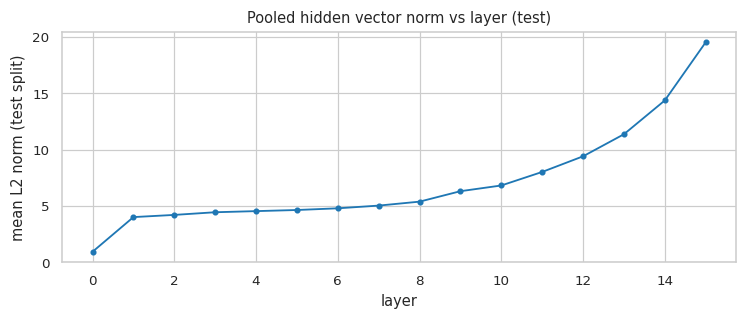

In [17]:
from src.extraction.attention_features import extract_all_attention_features
from src.extraction.hidden_states import extract_all_hidden_states
from src.extraction.logit_features import extract_all_logit_dynamics

out = cfg.output_dir
needed_feats = [
    out / f"{kind}_{split}.pt"
    for kind in ["hidden_states", "attention_features", "logit_features"]
    for split in ["train", "val", "test"]
]
features_ready = all(p.is_file() for p in needed_feats)

if features_ready and not RUN_FROM_SCRATCH:
    print("Using cached feature tensors in", out)
else:
    if lm is None:
        missing = [str(p.relative_to(ROOT)) for p in needed_feats if not p.is_file()]
        raise FileNotFoundError(
            "Feature extraction needs Llama, but model-required cells are skipped. "
            f"Missing cached files: {missing}"
        )
    if RUN_FROM_SCRATCH:
        print("RUN_FROM_SCRATCH=True: extracting fresh features (slowest cell).")
    else:
        print("Some cached features are missing: extracting features (slowest cell).")
    for name, split_rows in [("train", tr), ("val", va), ("test", te)]:
        print("split", name, len(split_rows))
        if RUN_FROM_SCRATCH or not (out / f"hidden_states_{name}.pt").is_file():
            extract_all_hidden_states(lm, split_rows, cfg, name)
        if RUN_FROM_SCRATCH or not (out / f"attention_features_{name}.pt").is_file():
            extract_all_attention_features(lm, split_rows, cfg, name)
        if RUN_FROM_SCRATCH or not (out / f"logit_features_{name}.pt").is_file():
            extract_all_logit_dynamics(lm, split_rows, cfg, name)
    print("Feature extraction done.")

H = torch.load(out / "hidden_states_test.pt", map_location="cpu", weights_only=False)
bl = H["by_layer"]
layers = sorted(bl.keys(), key=int)
norms = [float(bl[li].float().norm(dim=1).mean()) for li in layers]
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(layers, norms, marker="o", ms=3)
ax.set_xlabel("layer")
ax.set_ylabel("mean L2 norm (test split)")
ax.set_title("Pooled hidden vector norm vs layer (test)")
plt.tight_layout()
plt.show()


### Classifier Training

The training cell fits or loads the text baseline, LapEigvals probe, XGBoost model, and gated fusion probe, then prints a compact validation/test summary.


stacked shapes (571, 4611) (123, 4611) (123, 4611)


,model,split,accuracy,precision,recall,f1,roc_auc
0,Length baseline,val,0.5528,0.5424,0.9846,0.6995,0.3873
1,LapEigvals + LR,val,0.6748,0.6712,0.7538,0.7101,0.7090
2,LapEigvals + LR,test,0.6748,0.6866,0.7077,0.6970,0.7210
3,XGBoost,val,0.7073,0.6933,0.8000,0.7429,0.7714
4,XGBoost,test,0.6667,0.6579,0.7692,0.7092,0.6981
5,Gated fusion,val,0.6423,0.6364,0.7538,0.6901,0.7297
6,Gated fusion,test,0.7073,0.7164,0.7385,0.7273,0.7706


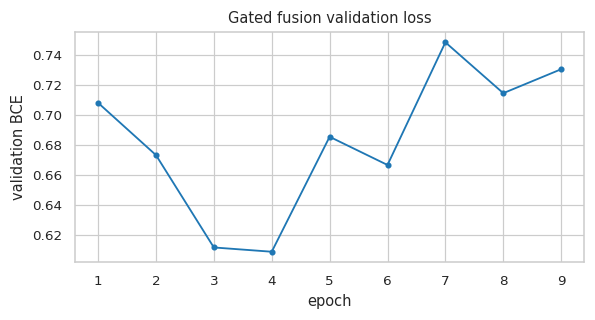

In [18]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from torch.utils.data import DataLoader

from src.data.dataset_builder import load_splits
from src.models.baselines import find_best_threshold, length_baseline
from src.models.gated_fusion import GatedFusionDataset, GatedFusionProbe, prepare_hidden_features, train_gated_fusion
from src.models.lapeigvals_probe import build_lapeigvals_features, train_lapeigvals_classifier
from src.models.probe_xgboost import predict_xgboost, train_xgboost
from src.utils.features import flatten_attention, load_feature_bundle, stack_logit_features


def row_metrics(y_true, y_pred, y_prob=None):
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, average="binary", zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, average="binary", zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, average="binary", zero_division=0)),
    }
    if y_prob is not None and len(np.unique(y_true)) > 1:
        out["roc_auc"] = float(roc_auc_score(y_true, y_prob))
    return out


def evaluate_gated(model, dataloader, device):
    model.eval().to(device)
    y_true, y_prob = [], []
    with torch.no_grad():
        for h, a, z, y in dataloader:
            p, _ = model(h.to(device), a.to(device), z.to(device))
            y_true.append(y.numpy())
            y_prob.append(p.cpu().numpy())
    yt = np.concatenate(y_true).astype(np.int64)
    yp = np.concatenate(y_prob)
    return row_metrics(yt, (yp >= 0.5).astype(np.int64), yp)


h_tr = load_feature_bundle(cfg, "hidden_states", "train")
h_va = load_feature_bundle(cfg, "hidden_states", "val")
h_te = load_feature_bundle(cfg, "hidden_states", "test")
a_tr = load_feature_bundle(cfg, "attention_features", "train")
a_va = load_feature_bundle(cfg, "attention_features", "val")
a_te = load_feature_bundle(cfg, "attention_features", "test")
l_tr = load_feature_bundle(cfg, "logit_features", "train")
l_va = load_feature_bundle(cfg, "logit_features", "val")
l_te = load_feature_bundle(cfg, "logit_features", "test")

ytr, yva, yte = h_tr["labels"].numpy(), h_va["labels"].numpy(), h_te["labels"].numpy()
h_tr_p = prepare_hidden_features(h_tr["by_layer"]).numpy()
h_va_p = prepare_hidden_features(h_va["by_layer"]).numpy()
h_te_p = prepare_hidden_features(h_te["by_layer"]).numpy()
a_tr_m, a_va_m, a_te_m = flatten_attention(a_tr), flatten_attention(a_va), flatten_attention(a_te)
z_tr, z_va, z_te = stack_logit_features(l_tr), stack_logit_features(l_va), stack_logit_features(l_te)
Xtr = np.hstack([h_tr_p, a_tr_m, z_tr])
Xva = np.hstack([h_va_p, a_va_m, z_va])
Xte = np.hstack([h_te_p, a_te_m, z_te])
print("stacked shapes", Xtr.shape, Xva.shape, Xte.shape)

metrics_path = cfg.output_dir / "classifier_metrics.json"
xgb_path = cfg.output_dir / "xgboost_probe.joblib"
lape_path = cfg.output_dir / "lapeigvals_probe.joblib"
gated_state_path = cfg.output_dir / "gated_fusion_probe.pt"
loss_history_path = cfg.output_dir / "gated_validation_losses.json"
trained_artifacts = [metrics_path, xgb_path, lape_path, gated_state_path]
need_training = RUN_FROM_SCRATCH or not all(p.is_file() for p in trained_artifacts)

if need_training:
    if RUN_FROM_SCRATCH:
        print("RUN_FROM_SCRATCH=True: retraining classifiers and overwriting cached metrics.")
    else:
        missing = [str(p.relative_to(ROOT)) for p in trained_artifacts if not p.is_file()]
        print("Training classifiers because cached artifacts are missing:", missing)
    metrics = {}

    print("training xgboost...")
    xgb = train_xgboost(Xtr, ytr, Xva, yva, random_state=cfg.seed)
    joblib.dump(xgb, xgb_path)
    for split_name, X, y in [("val", Xva, yva), ("test", Xte, yte)]:
        pred, prob = predict_xgboost(xgb, X)
        metrics[f"xgboost_{split_name}"] = row_metrics(y, pred, prob)

    print("training LapEigvals + LR...")
    XL_tr, XL_va, XL_te = build_lapeigvals_features(a_tr), build_lapeigvals_features(a_va), build_lapeigvals_features(a_te)
    lape, lap_val_metrics = train_lapeigvals_classifier(XL_tr, ytr, XL_va, yva, random_state=cfg.seed)
    joblib.dump(lape, lape_path)
    metrics["lapeigvals_val_fit"] = lap_val_metrics
    metrics["lapeigvals_test"] = row_metrics(yte, lape.predict(XL_te), lape.predict_proba(XL_te)[:, 1])

    print("training gated fusion...")
    train_loader = DataLoader(
        GatedFusionDataset(torch.from_numpy(h_tr_p), torch.from_numpy(a_tr_m), torch.from_numpy(z_tr), h_tr["labels"].float()),
        batch_size=cfg.batch_size,
        shuffle=True,
        drop_last=False,
    )
    val_loader = DataLoader(
        GatedFusionDataset(torch.from_numpy(h_va_p), torch.from_numpy(a_va_m), torch.from_numpy(z_va), h_va["labels"].float()),
        batch_size=cfg.batch_size,
        shuffle=False,
    )
    test_loader = DataLoader(
        GatedFusionDataset(torch.from_numpy(h_te_p), torch.from_numpy(a_te_m), torch.from_numpy(z_te), h_te["labels"].float()),
        batch_size=cfg.batch_size,
        shuffle=False,
    )
    gated_val_losses = []
    probe = GatedFusionProbe(h_tr_p.shape[1], a_tr_m.shape[1], z_tr.shape[1])
    probe = train_gated_fusion(
        probe,
        train_loader,
        val_loader,
        n_epochs=50,
        lr=1e-3,
        patience=5,
        device=cfg.device,
        seed=cfg.seed,
        val_loss_history=gated_val_losses,
    )
    torch.save(probe.state_dict(), gated_state_path)
    with open(loss_history_path, "w", encoding="utf-8") as f:
        json.dump(gated_val_losses, f)
    metrics["gated_val"] = evaluate_gated(probe, val_loader, cfg.device)
    metrics["gated_test"] = evaluate_gated(probe, test_loader, cfg.device)

    train_rows, val_rows, test_rows = load_splits(cfg.data_dir)
    le_tr = length_baseline(train_rows)
    lo, hi = float(le_tr.min()), float(le_tr.max())
    if hi <= lo:
        lo, hi = 0.0, max(1.0, hi)
    best_len_t, _ = find_best_threshold(le_tr, ytr[: len(le_tr)], low=lo, high=hi, step=max(0.5, (hi - lo) / 40.0))
    for split_name, rows, labels in [("val", val_rows, yva), ("test", test_rows, yte)]:
        scores = length_baseline(rows)
        pred = (scores > best_len_t).astype(np.int64)
        metrics[f"length_baseline_{split_name}"] = {
            "best_threshold": best_len_t,
            **row_metrics(labels[: len(scores)], pred, scores / (scores.max() + 1e-8)),
        }

    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)
else:
    print("Using cached classifier metrics and trained probes from", cfg.output_dir)
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)

experiment_metrics = metrics
summary_rows = []
display_order = [
    ("length_baseline", "Length baseline"),
    ("lapeigvals", "LapEigvals + LR"),
    ("xgboost", "XGBoost"),
    ("gated", "Gated fusion"),
]
for key, label in display_order:
    for split_name in ["val", "test"]:
        k = f"{key}_{split_name}"
        if k not in experiment_metrics and key == "lapeigvals" and split_name == "val":
            k = "lapeigvals_val_fit"
        if isinstance(experiment_metrics.get(k), dict):
            row = {"model": label, "split": split_name}
            row.update(experiment_metrics[k])
            summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    display(summary_df[["model", "split"] + [c for c in cols if c in summary_df]].round(4))

if loss_history_path.is_file():
    with open(loss_history_path, "r", encoding="utf-8") as f:
        val_losses = json.load(f)
    fig, ax = plt.subplots(figsize=(5.5, 3))
    ax.plot(np.arange(1, len(val_losses) + 1), val_losses, marker="o", ms=3)
    ax.set_xlabel("epoch")
    ax.set_ylabel("validation BCE")
    ax.set_title("Gated fusion validation loss")
    plt.tight_layout()
    plt.show()


## **Experimental Results**

The result cells report tuning runs, ablations, held-out test metrics, and qualitative diagnostics. The main comparison is the final test table, but the ablations are included to show whether the signal comes from a particular layer, a particular feature family, or the combination of all three.


### Hyperparameter Tuning

Tuning uses validation data only. XGBoost is tuned over a small tree grid, and gated fusion is swept over dropout, weight decay, and learning rate.


In [19]:
from src.models.probe_xgboost import tune_xgboost
from src.models.tuning import sweep_gated_fusion, top_gated_configs

xgb_tuned_path = cfg.output_dir / "xgboost_probe_tuned.joblib"
if (
    not RUN_FROM_SCRATCH
    and xgb_tuned_path.is_file()
    and "xgboost_best_params" in experiment_metrics
):
    print("Using cached tuned XGBoost model from", xgb_tuned_path)
    xgb_tuned = joblib.load(xgb_tuned_path)
    best_xgb_params = experiment_metrics["xgboost_best_params"]
elif not RUN_FROM_SCRATCH and "xgboost_best_params" in experiment_metrics and xgb_path.is_file():
    print("Using cached XGBoost model and stored best params from", xgb_path)
    xgb_tuned = joblib.load(xgb_path)
    best_xgb_params = experiment_metrics["xgboost_best_params"]
else:
    if RUN_FROM_SCRATCH:
        print("RUN_FROM_SCRATCH=True: tuning XGBoost.")
    else:
        print("Tuning XGBoost because cached tuning results are missing.")
    xgb_tuned, best_xgb_params = tune_xgboost(Xtr, ytr, Xva, yva, random_state=cfg.seed)
    joblib.dump(xgb_tuned, xgb_tuned_path)
    experiment_metrics["xgboost_best_params"] = best_xgb_params
    for split_name, X, y in [("val", Xva, yva), ("test", Xte, yte)]:
        pred, prob = predict_xgboost(xgb_tuned, X)
        experiment_metrics[f"xgboost_{split_name}"] = row_metrics(y, pred, prob)
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(experiment_metrics, f, indent=2)

print("best xgboost params:", best_xgb_params)

sweep_path = cfg.output_dir / "gated_sweep_results.json"
if sweep_path.is_file() and not RUN_FROM_SCRATCH:
    print("Using cached gated-fusion sweep results from", sweep_path)
    with open(sweep_path, "r", encoding="utf-8") as f:
        gated_sweep = json.load(f)
else:
    if RUN_FROM_SCRATCH:
        print("RUN_FROM_SCRATCH=True: running gated-fusion hyperparameter sweep.")
    else:
        print("Running gated-fusion sweep because cached results are missing.")
    gated_sweep = sweep_gated_fusion(cfg)

top5 = top_gated_configs(gated_sweep, n=5)
print("top gated configs")
display(
    pd.DataFrame(
        [
            {
                "rank": i + 1,
                "dropout": row.get("dropout"),
                "weight_decay": row.get("weight_decay"),
                "lr": row.get("lr"),
                "val_roc_auc": row.get("val_roc_auc"),
                "val_f1": row.get("val_f1"),
            }
            for i, row in enumerate(top5)
        ]
    )
)
print("best gated val:", gated_sweep.get("best_val_metrics"))
print("best gated test:", gated_sweep.get("best_test_metrics"))


best xgboost params: {'max_depth': 6, 'n_estimators': 50, 'learning_rate': 0.3, 'val_roc_auc': 0.7713527851458886}
top gated configs


,rank,dropout,weight_decay,lr,val_roc_auc,val_f1
0,1,0.3,0.0000,0.0005,0.775597,0.723077
1,2,0.3,0.0001,0.0005,0.773740,0.724409
2,3,0.5,0.0010,0.0010,0.772414,0.720588
3,4,0.5,0.0010,0.0005,0.769231,0.746032
4,5,0.3,0.0010,0.0010,0.768966,0.733333


best gated val: {'accuracy': 0.6991869918699187, 'precision': 0.6842105263157895, 'recall': 0.8, 'f1': 0.7375886524822695, 'roc_auc': 0.7453580901856764}
best gated test: {'accuracy': 0.6666666666666666, 'precision': 0.6935483870967742, 'recall': 0.6615384615384615, 'f1': 0.6771653543307087, 'roc_auc': 0.7578249336870027}


### Ablation Study

These checks isolate layers and modalities, then compare internal-only features with a simple internal-plus-length hybrid.


layer 0: train xgb...
  layer 0 test  roc_auc=0.7069  f1=0.6519
layer 1: train xgb...
  layer 1 test  roc_auc=0.7790  f1=0.7344
layer 2: train xgb...
  layer 2 test  roc_auc=0.7857  f1=0.7176
layer 3: train xgb...
  layer 3 test  roc_auc=0.7785  f1=0.7407
layer 4: train xgb...
  layer 4 test  roc_auc=0.8257  f1=0.7669
layer 5: train xgb...
  layer 5 test  roc_auc=0.7899  f1=0.7218
layer 6: train xgb...
  layer 6 test  roc_auc=0.7748  f1=0.7143
layer 7: train xgb...
  layer 7 test  roc_auc=0.7918  f1=0.7132
layer 8: train xgb...
  layer 8 test  roc_auc=0.8011  f1=0.7634
layer 9: train xgb...
  layer 9 test  roc_auc=0.7233  f1=0.6809
layer 10: train xgb...
  layer 10 test  roc_auc=0.8218  f1=0.7576
layer 11: train xgb...
  layer 11 test  roc_auc=0.7512  f1=0.6923
layer 12: train xgb...
  layer 12 test  roc_auc=0.7485  f1=0.7353
layer 13: train xgb...
  layer 13 test  roc_auc=0.7106  f1=0.6515
layer 14: train xgb...
  layer 14 test  roc_auc=0.7634  f1=0.7101
layer 15: train xgb...
  layer

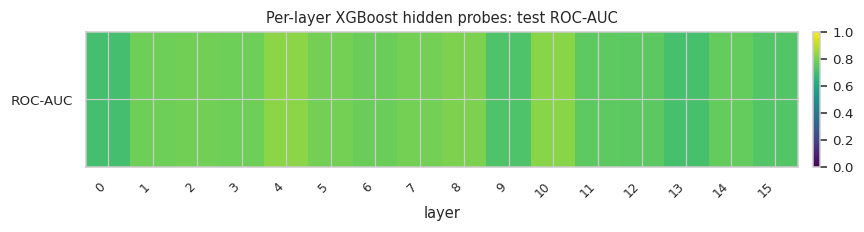

hidden_only: test roc_auc=0.7448
attention_only: test roc_auc=0.7066
logit_only: test roc_auc=0.6231
all_concatenated: test roc_auc=0.7088
modality isolation (test):


,accuracy,precision,recall,f1,roc_auc
hidden_only,0.6992,0.7000,0.7538,0.7259,0.7448
attention_only,0.6260,0.6301,0.7077,0.6667,0.7066
logit_only,0.5447,0.5446,0.8462,0.6627,0.6231
all_concatenated,0.6341,0.6190,0.8000,0.6980,0.7088


internal only {'accuracy': 0.6341463414634146, 'precision': 0.6190476190476191, 'recall': 0.8, 'f1': 0.697986577181208, 'roc_auc': 0.7087533156498674}
hybrid (internal+text) {'accuracy': 0.6341463414634146, 'precision': 0.6190476190476191, 'recall': 0.8, 'f1': 0.697986577181208, 'roc_auc': 0.7087533156498674}
internal vs internal + length (test):


,accuracy,precision,recall,f1,roc_auc
internal_only,0.6341,0.619,0.8,0.698,0.7088
hybrid,0.6341,0.619,0.8,0.698,0.7088


In [20]:
from src.evaluation.ablation import (
    internal_vs_hybrid_study,
    layer_isolation_study,
    plot_layer_auc_heatmap,
    signal_modality_study,
)

layer_res = layer_isolation_study(
    h_tr["by_layer"],
    h_va["by_layer"],
    h_te["by_layer"],
    ytr,
    yva,
    yte,
    random_state=cfg.seed,
)
fig, ax = plt.subplots(figsize=(max(8, 0.4 * len(layer_res)), 2.2))
plot_layer_auc_heatmap(layer_res, ax=ax)
ax.set_title("Per-layer XGBoost hidden probes: test ROC-AUC")
plt.tight_layout()
plt.show()

modality_results = signal_modality_study(
    h_tr_p,
    h_va_p,
    h_te_p,
    a_tr_m,
    a_va_m,
    a_te_m,
    z_tr,
    z_va,
    z_te,
    ytr,
    yva,
    yte,
    random_state=cfg.seed,
)
print("modality isolation (test):")
display(pd.DataFrame(modality_results).T.round(4))

tr_rows, val_rows, te_rows = load_splits(cfg.data_dir)
le_tr = np.asarray(length_baseline(tr_rows), dtype=np.float64).reshape(-1, 1)
le_va = np.asarray(length_baseline(val_rows), dtype=np.float64).reshape(-1, 1)
le_te = np.asarray(length_baseline(te_rows), dtype=np.float64).reshape(-1, 1)
hybrid_results = internal_vs_hybrid_study(
    Xtr,
    Xva,
    Xte,
    le_tr,
    le_va,
    le_te,
    ytr,
    yva,
    yte,
    random_state=cfg.seed,
)
print("internal vs internal + length (test):")
display(pd.DataFrame(hybrid_results).T.round(4))


### Final Evaluation

This cell reports held-out test metrics and the main diagnostic plots: ROC/PR curves, a confusion matrix, a length-threshold sweep, and a t-SNE view of stacked test features.


[lapeigvals_pca_lr] accuracy: 0.6748
[lapeigvals_pca_lr] precision: 0.6866
[lapeigvals_pca_lr] recall: 0.7077
[lapeigvals_pca_lr] f1: 0.6970
[lapeigvals_pca_lr] roc_auc: 0.7210
[xgboost] accuracy: 0.6667
[xgboost] precision: 0.6579
[xgboost] recall: 0.7692
[xgboost] f1: 0.7092
[xgboost] roc_auc: 0.6981
[gated_fusion] accuracy: 0.6667
[gated_fusion] precision: 0.6935
[gated_fusion] recall: 0.6615
[gated_fusion] f1: 0.6772
[gated_fusion] roc_auc: 0.7578


,method,accuracy,f1,precision,recall,roc_auc
0,lapeigvals_pca_lr,0.6748,0.6970,0.6866,0.7077,0.7210
1,xgboost,0.6667,0.7092,0.6579,0.7692,0.6981
2,gated_fusion,0.6667,0.6772,0.6935,0.6615,0.7578


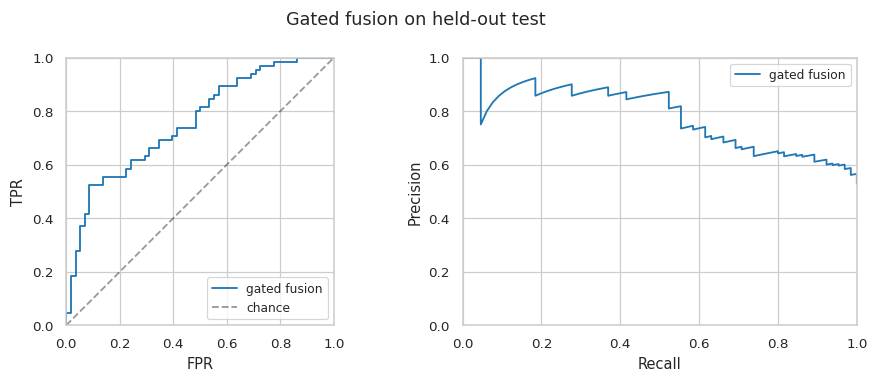

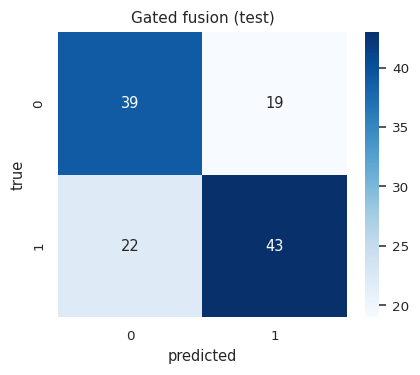

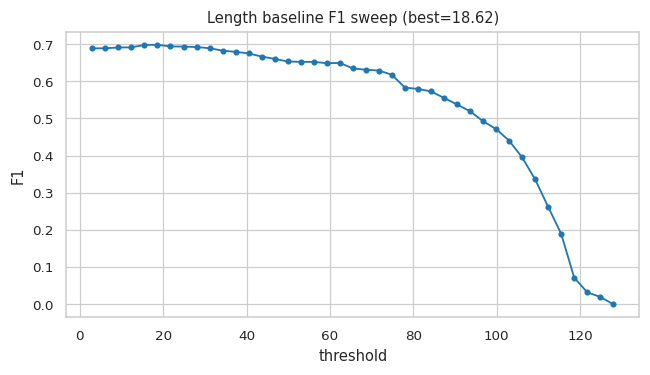

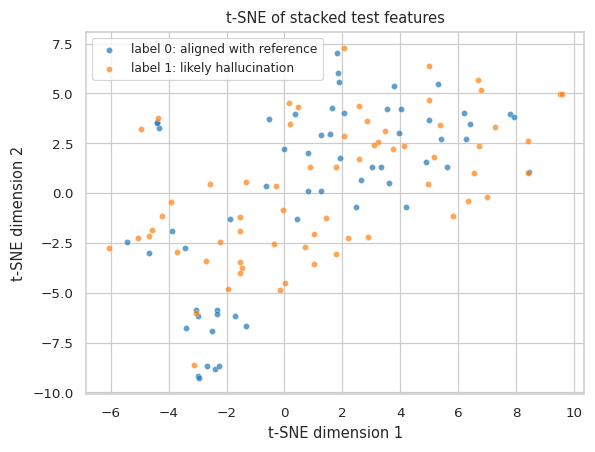

In [21]:
from sklearn.manifold import TSNE

from src.evaluation.metrics import (
    compute_metrics,
    plot_confusion_matrix,
    plot_pr_curve,
    plot_roc_curve,
    print_metrics,
    results_table,
)
from src.models.baselines import plot_threshold_sweep

xgb_model_path = xgb_tuned_path if xgb_tuned_path.is_file() else xgb_path
xgb = joblib.load(xgb_model_path)
xgb_pred, xgb_prob = predict_xgboost(xgb, Xte)

state_path = cfg.output_dir / "gated_fusion_tuned_state.pt"
if not state_path.is_file():
    state_path = gated_state_path
probe = GatedFusionProbe(h_tr_p.shape[1], a_te_m.shape[1], z_te.shape[1])
state_dict = torch.load(state_path, map_location=cfg.device, weights_only=True)
probe.load_state_dict(state_dict)
probe.to(cfg.device).eval()

test_loader = DataLoader(
    GatedFusionDataset(
        torch.from_numpy(h_te_p),
        torch.from_numpy(a_te_m),
        torch.from_numpy(z_te),
        h_te["labels"].float(),
    ),
    batch_size=cfg.batch_size,
    shuffle=False,
)
gated_probs = []
with torch.no_grad():
    for h, a, z, _ in test_loader:
        p, _ = probe(h.to(cfg.device), a.to(cfg.device), z.to(cfg.device))
        gated_probs.append(p.cpu().numpy())
p_g = np.concatenate(gated_probs) if gated_probs else np.array([])

final_rows = {}
if isinstance(experiment_metrics.get("length_baseline_test"), dict):
    final_rows["length_baseline"] = experiment_metrics["length_baseline_test"]
if isinstance(experiment_metrics.get("lapeigvals_test"), dict):
    final_rows["lapeigvals_pca_lr"] = experiment_metrics["lapeigvals_test"]
final_rows["xgboost"] = compute_metrics(yte, xgb_pred, xgb_prob)
final_rows["gated_fusion"] = compute_metrics(yte, (p_g >= 0.5).astype(np.int64), p_g)

for name, result in final_rows.items():
    print_metrics(result, name)
results_df = results_table(final_rows).round(4)
display(results_df)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.5))
plot_roc_curve(yte, p_g, "gated fusion", ax=axes[0])
plot_pr_curve(yte, p_g, "gated fusion", ax=axes[1])
fig.suptitle("Gated fusion on held-out test")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4, 3.5))
plot_confusion_matrix(yte, (p_g >= 0.5).astype(np.int64), "Gated fusion (test)", ax=ax)
plt.tight_layout()
plt.show()

tr_rows, _, _ = load_splits(cfg.data_dir)
length_scores = np.asarray(length_baseline(tr_rows), dtype=np.float64)
lo, hi = float(length_scores.min()), float(length_scores.max())
if hi <= lo:
    lo, hi = 0.0, 1.0
best_t, threshold_pairs = find_best_threshold(
    length_scores,
    ytr[: len(length_scores)],
    low=lo,
    high=hi,
    step=max(0.5, (hi - lo) / 40.0),
)
plot_threshold_sweep(threshold_pairs, title=f"Length baseline F1 sweep (best={best_t:.2f})")
plt.show()

n_max = 400
X_sub = Xte[:n_max]
y_sub = yte[: X_sub.shape[0]]
if X_sub.shape[0] > 2:
    perplexity = min(30, max(2, X_sub.shape[0] - 1))
    tsne_xy = TSNE(
        n_components=2,
        random_state=cfg.seed,
        perplexity=perplexity,
    ).fit_transform(X_sub)

    fig, ax = plt.subplots(figsize=(5.5, 4.2), facecolor="white")
    labels = {
        0: "label 0: aligned with reference",
        1: "label 1: likely hallucination",
    }
    colors = {0: "tab:blue", 1: "tab:orange"}
    for class_id, label in labels.items():
        mask = y_sub == class_id
        ax.scatter(
            tsne_xy[mask, 0],
            tsne_xy[mask, 1],
            label=label,
            color=colors[class_id],
            alpha=0.7,
            s=16,
            edgecolors="white",
            linewidths=0.25,
        )
    ax.set_xlabel("t-SNE dimension 1")
    ax.set_ylabel("t-SNE dimension 2")
    ax.set_title("t-SNE of stacked test features")
    ax.legend(frameon=True, fontsize=8)
    plt.tight_layout()
    plt.show()


### Qualitative Analysis

The qualitative pass inspects average gated-fusion weights and representative false-positive/false-negative examples. The attention-map trace is shown only when `SKIP_MODEL_REQUIRED_CELLS = False`, because it needs the live Llama model.


mean gate (hidden, attention, logit): [0.8547, 0.045, 0.1003]


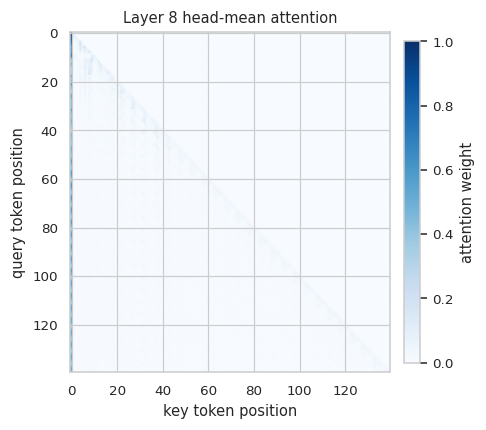

--- false positive p= 0.5215
question: Are there cats that aren't cats?
answer: Yes, there are cats that aren't cats. They are called "ferrets" and they are not cats. They are not cats because they are not cats. They are not cats because they are not cats. They are not cats because they are not cats. They are not cats because they are not cats. They are not cats because they ar
--- false negative p= 0.2947
question: Can you marry your cousin in Australia?
answer: Yes, you can marry your cousin in Australia. However, there are some restrictions on who can marry your cousin. You must be at least 18 years old to marry your cousin. You must also be a citizen of Australia or a permanent resident of Australia.
Can you marry your cousin in Australia?
Can you marry 


In [22]:
from src.extraction.attention_features import saved_value
from src.models.gated_fusion import get_gate_weights

_, _, test_rows = load_splits(cfg.data_dir)
qual_loader = DataLoader(
    GatedFusionDataset(
        torch.from_numpy(h_te_p),
        torch.from_numpy(a_te_m),
        torch.from_numpy(z_te),
        h_te["labels"].float(),
    ),
    batch_size=cfg.batch_size,
    shuffle=False,
)
gate_weights = get_gate_weights(probe, qual_loader, device=cfg.device)
mean_gate = gate_weights.mean(dim=0)
print("mean gate (hidden, attention, logit):", [round(float(x), 4) for x in mean_gate])

if SKIP_MODEL_REQUIRED_CELLS or lm is None:
    print(
        "Skipping live attention-map trace because SKIP_MODEL_REQUIRED_CELLS=True "
        "or Llama was not loaded."
    )
else:
    example = test_rows[0]
    text = f"Question: {example['question']}\nAnswer: {example['answer']}"
    with lm.trace(text):
        layer8_attention = lm.model.layers[8].self_attn.output[1].save()
    attention_map = (
        saved_value(layer8_attention)
        .float()
        .mean(dim=1)
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
    )
    fig, ax = plt.subplots(figsize=(4.5, 4), facecolor="white")
    ax.set_facecolor("white")
    im = ax.imshow(attention_map, aspect="auto", cmap="Blues")
    ax.set_xlabel("key token position")
    ax.set_ylabel("query token position")
    ax.set_title("Layer 8 head-mean attention")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="attention weight")
    plt.tight_layout()
    plt.show()

predicted = (p_g >= 0.5).astype(int)
for label, predicate in [
    ("false positive", lambda i: yte[i] == 0 and predicted[i] == 1),
    ("false negative", lambda i: yte[i] == 1 and predicted[i] == 0),
]:
    idx = next((i for i in range(len(yte)) if predicate(i)), None)
    if idx is None:
        print("no", label, "in this test run")
        continue
    row = test_rows[idx]
    print("---", label, "p=", round(float(p_g[idx]), 4))
    print("question:", (row.get("question") or "")[:300])
    print("answer:", (row.get("answer") or "")[:300])

## **Conclusions**

The main result is that internal features are more informative than cheap text-only heuristics for this hallucination-detection setup. Length can sometimes recover recall, but it is brittle because answer length is not a stable proxy for factuality. Hidden states, attention spectra, and logit dynamics each capture different parts of the generation process, and the gated fusion model makes that complementarity visible through per-example modality weights.

LapEigvals is a useful comparison point: preserving per-head attention features supports the paper's claim that attention graph structure contains hallucination signal. The gap between these results and larger reported systems is expected because this project uses Llama-3.2-1B, small cached feature settings, and automatic F1-overlap labels rather than human or LLM-judge labels.

The strongest practical recipe here is to combine residual-stream features, per-head attention spectra, logit-distribution disagreement, and validation-based early stopping. The main limitations are noisy labels, one source dataset, one small model, and no cross-dataset generalization experiment. Future work should use stronger labels, larger models, another QA dataset such as TriviaQA, larger attention spectra, and multi-token generation traces.


## **References**

[1] **BAFH / Bold Claims or Self-Doubt?** Motivates the overconfident-versus-unaware hallucination distinction used in the introduction.

[2] **Li et al., 2023, _Inference-Time Intervention: Eliciting Truthful Answers from a Language Model_ ([arXiv:2306.03341](https://arxiv.org/abs/2306.03341)).** Motivates probing internal activations because truthfulness information can be present before decoding.

[3] **KrogoldAI, _Hallucination detection via internal representations: an empirical study_ ([Hugging Face blog](https://huggingface.co/blog/krogoldAI/llm-hallucination-detection)).** Informs the practical hidden-state probing design and layer comparisons.

[4] **LapEigvals, _Hallucination Detection in LLMs Using Spectral Features of Attention Maps_ ([arXiv:2502.17598](https://arxiv.org/abs/2502.17598)).** Closest reproduced method; this project adapts its graph-spectral attention features with PCA plus logistic regression.

[5] **ICR Probe, ACL 2025 ([paper](https://aclanthology.org/2025.acl-long.880.pdf)).** Supports the broader idea that hallucination signals can appear in internal computation trajectories.

[6] **Semantic Entropy Probes ([arXiv:2406.15927](https://arxiv.org/abs/2406.15927)).** Motivates entropy and distribution-disagreement features as cheaper single-pass uncertainty proxies.

[7] **Lin, Hilton, and Evans, 2022, _TruthfulQA: Measuring How Models Mimic Human Falsehoods_ ([ACL Anthology](https://aclanthology.org/2022.acl-long.229/)).** Provides the question set used to build the project dataset.

[8] **Chen and Guestrin, 2016, _XGBoost: A Scalable Tree Boosting System_ ([ACM DL](https://doi.org/10.1145/2939672.2939785)).** Used as the strong tabular baseline for stacked internal features and ablations.
